# Hebbian Learning and Catastrophic Forgetting on MNIST

This is the self-contained Colab notebook for the Hebbian part of the team project. It does not import or alter the repository's existing model code.

The workflow has two locked stages:

1. Select a competent Hebbian rule using ordinary shuffled MNIST validation performance only.
2. Freeze that choice, then measure forgetting on digits **0-4 followed by 5-9** under sequential and interleaved conditions.

The main comparison is made when models reach the same new-task validation accuracy. A model that fails to learn the new task is not considered resistant to forgetting.

## 1. Runtime check

This file is locked for the full experiment. Use a Colab GPU runtime, run every cell in order, and do not change the frozen configuration.

In [ ]:
!pip -q install tabulate

import json
import platform
import shutil
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision import datasets, transforms

print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Python: 3.12.13
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
Device: Tesla T4


## 2. Embedded Hebbian implementation

The following cell contains the complete local-learning model, deterministic data protocol, balanced interleaving, evaluation, matched-checkpoint, and diagnostic code. Hidden-layer updates never receive labels or backpropagated errors.

In [ ]:
"""Self-contained Hebbian MNIST continual-learning implementation.

This module intentionally does not import the repository's existing ``src``
package. The matching Colab notebook embeds this file verbatim so it can run as
a standalone upload while leaving all teammate code untouched.
"""

from __future__ import annotations

import copy
import random
from collections import defaultdict
from dataclasses import asdict, dataclass
from typing import Dict, Iterable, Iterator, Mapping, Sequence

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import BatchSampler, ConcatDataset, DataLoader, Dataset, Subset


OLD_CLASSES = (0, 1, 2, 3, 4)
NEW_CLASSES = (5, 6, 7, 8, 9)
HEBBIAN_VARIANTS = ("centered", "oja", "hard_wta", "soft_wta")
OUTPUT_RULES = ("delta", "teacher_hebb")


@dataclass(frozen=True)
class HebbianConfig:
    """Hyperparameters for the fixed-capacity local-learning MLP."""

    num_inputs: int = 784
    num_hidden: int = 100
    num_outputs: int = 10
    variant: str = "oja"
    activation_type: str = "sigmoid"
    bias: bool = False
    hidden_lr: float = 1e-3
    output_lr: float = 1e-2
    output_rule: str = "delta"
    temperature: float = 0.2
    top_k: int = 5
    normalize_hidden: bool = True
    weight_decay: float = 0.0
    eps: float = 1e-8


@dataclass(frozen=True)
class ExperimentConfig:
    """Shared IID-selection and continual-learning protocol."""

    seed: int = 0
    batch_size: int = 64
    train_per_class: int = 5000
    iid_max_steps: int = 2000
    phase1_max_steps: int = 2000
    phase2_max_steps: int = 2000
    eval_every_steps: int = 100
    old_target_accuracy: float = 90.0
    matched_new_accuracies: tuple[float, ...] = (70.0, 80.0, 90.0)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed: int) -> None:
    """Seed Python, NumPy, PyTorch, CUDA, and deterministic CuDNN behavior."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class HebbianMLP(nn.Module):
    """A 784 -> hidden -> 10 MLP trained with explicit local updates.

    Hidden updates never use a label or backpropagated error. The output update
    uses only the output prediction/target and presynaptic hidden activity.
    Parameters have autograd disabled during learning; ``local_update`` applies
    all changes under ``torch.no_grad()``.
    """

    def __init__(self, config: HebbianConfig):
        super().__init__()
        if config.variant not in HEBBIAN_VARIANTS:
            raise ValueError(f"Unknown variant {config.variant!r}; choose from {HEBBIAN_VARIANTS}.")
        if config.output_rule not in OUTPUT_RULES:
            raise ValueError(f"Unknown output rule {config.output_rule!r}; choose from {OUTPUT_RULES}.")
        if config.hidden_lr <= 0 or config.output_lr <= 0:
            raise ValueError("Learning rates must be positive.")
        if config.temperature <= 0:
            raise ValueError("temperature must be positive.")
        if not 1 <= config.top_k <= config.num_hidden:
            raise ValueError("top_k must be between 1 and num_hidden.")

        self.config = config
        self.num_inputs = config.num_inputs
        self.num_hidden = config.num_hidden
        self.num_outputs = config.num_outputs
        self.lin1 = nn.Linear(config.num_inputs, config.num_hidden, bias=config.bias)
        self.lin2 = nn.Linear(config.num_hidden, config.num_outputs, bias=config.bias)
        if config.activation_type == "sigmoid":
            self.activation = torch.sigmoid
        elif config.activation_type == "tanh":
            self.activation = torch.tanh
        elif config.activation_type == "relu":
            self.activation = torch.relu
        elif config.activation_type == "identity":
            self.activation = lambda value: value
        else:
            raise ValueError("activation_type must be sigmoid, tanh, relu, or identity.")

        for parameter in self.parameters():
            parameter.requires_grad_(False)
        if config.normalize_hidden:
            self._normalise_hidden_rows()

    def _flatten(self, X: torch.Tensor) -> torch.Tensor:
        return X.reshape(-1, self.num_inputs)

    def hidden_activity(self, X: torch.Tensor) -> torch.Tensor:
        X = self._flatten(X)
        drive = self.lin1(X)
        base = self.activation(drive)
        if self.config.variant in ("centered", "oja"):
            return base
        if self.config.variant == "hard_wta":
            winners = torch.topk(base, k=self.config.top_k, dim=1).indices
            mask = torch.zeros_like(base)
            mask.scatter_(1, winners, 1.0)
            # Preserve an activity scale comparable with the dense variants.
            # Without this factor the readout signal is roughly H/k times
            # smaller and appeared not to learn within the screening budget.
            return base * mask * (self.num_hidden / self.config.top_k)
        responsibilities = torch.softmax(drive / self.config.temperature, dim=1)
        # Softmax responsibilities sum to one; multiply by H so that this
        # variant is not given an artificially tiny output-learning signal.
        return base * responsibilities * self.num_hidden

    def logits(self, X: torch.Tensor) -> torch.Tensor:
        return self.lin2(self.hidden_activity(X))

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.logits(X), dim=1)

    def proposed_updates(self, X: torch.Tensor, y: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Return local ascent/update directions without changing weights."""
        with torch.no_grad():
            X_flat = self._flatten(X)
            batch_size = X_flat.shape[0]
            hidden = self.hidden_activity(X_flat)

            if self.config.variant == "centered":
                hidden_update = hidden.T @ X_flat / batch_size
                hidden_update -= hidden_update.mean(dim=0, keepdim=True)
            elif self.config.variant == "oja":
                # Generalized Oja/Sanger update. Centering removes the common
                # sigmoid component and the triangular lateral term prevents
                # every unit from collapsing onto the first principal feature.
                learning_hidden = hidden - hidden.mean(dim=0, keepdim=True)
                correlation = learning_hidden.T @ X_flat / batch_size
                lateral = torch.tril(learning_hidden.T @ learning_hidden / batch_size)
                hidden_update = correlation - lateral @ self.lin1.weight
            else:
                correlation = hidden.T @ X_flat / batch_size
                oja_stabiliser = hidden.square().mean(dim=0).unsqueeze(1) * self.lin1.weight
                hidden_update = correlation - oja_stabiliser

            targets = F.one_hot(y, num_classes=self.num_outputs).to(dtype=X_flat.dtype)
            probabilities = torch.softmax(self.lin2(hidden), dim=1)
            if self.config.output_rule == "delta":
                output_signal = targets - probabilities
                output_update = output_signal.T @ hidden / batch_size
            else:
                output_signal = targets
                output_update = output_signal.T @ hidden / batch_size
                output_update -= output_update.mean(dim=0, keepdim=True)

            if self.config.weight_decay:
                hidden_update -= self.config.weight_decay * self.lin1.weight
                output_update -= self.config.weight_decay * self.lin2.weight

            updates: Dict[str, torch.Tensor] = {
                "lin1_weight": hidden_update,
                "lin2_weight": output_update,
            }
            if self.config.bias:
                hidden_bias_update = hidden.mean(dim=0)
                if self.config.variant == "centered":
                    hidden_bias_update -= hidden_bias_update.mean()
                updates["lin1_bias"] = hidden_bias_update
                updates["lin2_bias"] = output_signal.mean(dim=0)
            return {name: update.detach().clone() for name, update in updates.items()}

    def local_update(self, X: torch.Tensor, y: torch.Tensor) -> Dict[str, float]:
        updates = self.proposed_updates(X, y)
        with torch.no_grad():
            self.lin1.weight.add_(updates["lin1_weight"], alpha=self.config.hidden_lr)
            self.lin2.weight.add_(updates["lin2_weight"], alpha=self.config.output_lr)
            if self.config.bias:
                self.lin1.bias.add_(updates["lin1_bias"], alpha=self.config.hidden_lr)
                self.lin2.bias.add_(updates["lin2_bias"], alpha=self.config.output_lr)
            if self.config.normalize_hidden:
                self._normalise_hidden_rows()

        hidden = self.hidden_activity(X)
        return {
            "lin1_update_norm": updates["lin1_weight"].norm().item(),
            "lin2_update_norm": updates["lin2_weight"].norm().item(),
            "lin1_weight_norm": self.lin1.weight.norm().item(),
            "lin2_weight_norm": self.lin2.weight.norm().item(),
            "hidden_active_fraction": (hidden.abs() > self.config.eps).float().mean().item(),
        }

    def _normalise_hidden_rows(self) -> None:
        with torch.no_grad():
            norms = self.lin1.weight.norm(dim=1, keepdim=True).clamp_min(self.config.eps)
            self.lin1.weight.div_(norms)


def dataset_targets(dataset: Dataset) -> torch.Tensor:
    if isinstance(dataset, Subset):
        parent = dataset_targets(dataset.dataset)
        return parent[torch.as_tensor(dataset.indices, dtype=torch.long)]
    if isinstance(dataset, ConcatDataset):
        return torch.cat([dataset_targets(part) for part in dataset.datasets])
    if hasattr(dataset, "targets"):
        return torch.as_tensor(dataset.targets, dtype=torch.long)
    return torch.as_tensor([int(dataset[index][1]) for index in range(len(dataset))])


def stratified_train_valid_split(
    full_train_dataset: Dataset,
    train_per_class: int = 5000,
    seed: int = 0,
) -> tuple[Subset, Subset]:
    """Make an exact 50k/10k stratified split for standard MNIST."""
    targets = dataset_targets(full_train_dataset)
    generator = torch.Generator().manual_seed(seed)
    train_indices: list[int] = []
    valid_indices: list[int] = []
    for class_id in sorted(targets.unique().tolist()):
        class_indices = torch.where(targets == class_id)[0]
        if len(class_indices) <= train_per_class:
            raise ValueError(f"Class {class_id} has too few examples for the requested split.")
        shuffled = class_indices[torch.randperm(len(class_indices), generator=generator)]
        train_indices.extend(shuffled[:train_per_class].tolist())
        valid_indices.extend(shuffled[train_per_class:].tolist())
    return Subset(full_train_dataset, train_indices), Subset(full_train_dataset, valid_indices)


def restrict_to_classes(dataset: Dataset, classes: Sequence[int]) -> Subset:
    targets = dataset_targets(dataset)
    allowed = torch.as_tensor(tuple(classes), dtype=torch.long)
    mask = (targets.unsqueeze(1) == allowed.unsqueeze(0)).any(dim=1)
    return Subset(dataset, torch.where(mask)[0].tolist())


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool, seed: int) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
        generator=torch.Generator().manual_seed(seed),
        num_workers=0,
    )


class BalancedOldNewBatchSampler(BatchSampler):
    """Yield fixed-size batches containing equal numbers of old and new items."""

    def __init__(self, num_old: int, num_new: int, batch_size: int, steps_per_epoch: int, seed: int):
        if batch_size % 2:
            raise ValueError("Balanced interleaving requires an even batch size.")
        if min(num_old, num_new, steps_per_epoch) < 1:
            raise ValueError("Both datasets and steps_per_epoch must be non-empty.")
        self.num_old = num_old
        self.num_new = num_new
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.seed = seed
        self.epoch = 0

    @staticmethod
    def _stream(size: int, offset: int, generator: torch.Generator) -> Iterator[int]:
        while True:
            for index in torch.randperm(size, generator=generator).tolist():
                yield index + offset

    def __iter__(self) -> Iterator[list[int]]:
        generator = torch.Generator().manual_seed(self.seed + self.epoch)
        self.epoch += 1
        old_stream = self._stream(self.num_old, 0, generator)
        new_stream = self._stream(self.num_new, self.num_old, generator)
        half = self.batch_size // 2
        for _ in range(self.steps_per_epoch):
            batch = [next(old_stream) for _ in range(half)]
            batch.extend(next(new_stream) for _ in range(half))
            order = torch.randperm(self.batch_size, generator=generator).tolist()
            yield [batch[index] for index in order]

    def __len__(self) -> int:
        return self.steps_per_epoch


def make_balanced_interleaved_loader(
    old_dataset: Dataset,
    new_dataset: Dataset,
    batch_size: int,
    steps_per_epoch: int,
    seed: int,
) -> DataLoader:
    dataset = ConcatDataset([old_dataset, new_dataset])
    sampler = BalancedOldNewBatchSampler(
        len(old_dataset), len(new_dataset), batch_size, steps_per_epoch, seed
    )
    return DataLoader(dataset, batch_sampler=sampler, num_workers=0)


def build_mnist_protocol(full_train_dataset: Dataset, test_dataset: Dataset, config: ExperimentConfig):
    train_dataset, valid_dataset = stratified_train_valid_split(
        full_train_dataset, config.train_per_class, config.seed
    )
    datasets = {
        "train_joint": train_dataset,
        "valid_joint": valid_dataset,
        "test_joint": test_dataset,
        "train_old": restrict_to_classes(train_dataset, OLD_CLASSES),
        "train_new": restrict_to_classes(train_dataset, NEW_CLASSES),
        "valid_old": restrict_to_classes(valid_dataset, OLD_CLASSES),
        "valid_new": restrict_to_classes(valid_dataset, NEW_CLASSES),
        "test_old": restrict_to_classes(test_dataset, OLD_CLASSES),
        "test_new": restrict_to_classes(test_dataset, NEW_CLASSES),
    }
    evaluation_loaders = {
        name: make_loader(dataset, config.batch_size, False, config.seed)
        for name, dataset in datasets.items()
        if name.startswith("valid_") or name.startswith("test_")
    }
    return datasets, evaluation_loaders


def evaluate(model: HebbianMLP, loader: DataLoader, device: str) -> Dict:
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    seen_by_class: Dict[int, int] = {}
    correct_by_class: Dict[int, int] = {}
    confusion = torch.zeros(model.num_outputs, model.num_outputs, dtype=torch.long)
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            probabilities = model(X)
            predictions = probabilities.argmax(dim=1)
            loss = F.nll_loss(probabilities.clamp_min(1e-8).log(), y)
            total += y.numel()
            correct += (predictions == y).sum().item()
            loss_sum += loss.item() * y.numel()
            for target, prediction in zip(y.cpu().tolist(), predictions.cpu().tolist()):
                confusion[target, prediction] += 1
            for class_id in y.unique().tolist():
                mask = y == class_id
                seen = int(mask.sum().item())
                hits = int((predictions[mask] == y[mask]).sum().item())
                seen_by_class[int(class_id)] = seen_by_class.get(int(class_id), 0) + seen
                correct_by_class[int(class_id)] = correct_by_class.get(int(class_id), 0) + hits
    per_class = {
        class_id: 100.0 * correct_by_class.get(class_id, 0) / seen
        for class_id, seen in sorted(seen_by_class.items())
    }
    return {
        "loss": loss_sum / total,
        "micro_accuracy": 100.0 * correct / total,
        "macro_accuracy": float(np.mean(list(per_class.values()))),
        "per_class_accuracy": per_class,
        "confusion_matrix": confusion.tolist(),
        "num_examples": total,
    }


def evaluate_named_loaders(model: HebbianMLP, loaders: Mapping[str, DataLoader], device: str) -> Dict:
    metrics: Dict = {}
    for name, loader in loaders.items():
        result = evaluate(model, loader, device)
        for key in ("loss", "micro_accuracy", "macro_accuracy", "per_class_accuracy", "confusion_matrix"):
            metrics[f"{name}_{key}"] = result[key]
    return metrics


def _infinite_batches(loader: Iterable) -> Iterator:
    while True:
        yield from loader


def train_local_steps(
    model: HebbianMLP,
    train_loader: DataLoader,
    evaluation_loaders: Mapping[str, DataLoader],
    max_steps: int,
    eval_every_steps: int,
    device: str,
    metadata: Mapping | None = None,
    stop_metric: str | None = None,
    stop_value: float | None = None,
    checkpoint_metric: str | None = None,
    checkpoint_targets: Sequence[float] = (),
) -> tuple[list[Dict], int, Dict[float, Dict[str, torch.Tensor]]]:
    """Train by local update count and capture first matched-accuracy states."""
    if min(max_steps, eval_every_steps) < 1:
        raise ValueError("max_steps and eval_every_steps must be positive.")
    model.to(device)
    metadata = dict(metadata or {})
    records: list[Dict] = []
    checkpoints: Dict[float, Dict[str, torch.Tensor]] = {}
    old_examples_seen = 0
    new_examples_seen = 0

    def record(step: int, diagnostics: Mapping | None = None) -> Dict:
        row = {
            **metadata,
            "step": step,
            "examples_seen": old_examples_seen + new_examples_seen,
            "old_examples_seen": old_examples_seen,
            "new_examples_seen": new_examples_seen,
            **evaluate_named_loaders(model, evaluation_loaders, device),
        }
        if diagnostics:
            row.update(diagnostics)
        records.append(row)
        if checkpoint_metric:
            current = float(row.get(checkpoint_metric, float("-inf")))
            for target in checkpoint_targets:
                if target not in checkpoints and current >= target:
                    checkpoints[target] = copy.deepcopy(model.state_dict())
        return row

    first = record(0)
    if stop_metric and stop_value is not None and first.get(stop_metric, float("-inf")) >= stop_value:
        return records, 0, checkpoints

    diagnostic_sums: Dict[str, float] = {}
    diagnostic_count = 0
    for step, (X, y) in enumerate(_infinite_batches(train_loader), start=1):
        X, y = X.to(device), y.to(device)
        old_mask = torch.isin(y, torch.as_tensor(OLD_CLASSES, device=y.device))
        old_examples_seen += int(old_mask.sum().item())
        new_examples_seen += int((~old_mask).sum().item())
        diagnostics = model.local_update(X, y)
        diagnostic_count += 1
        for key, value in diagnostics.items():
            diagnostic_sums[key] = diagnostic_sums.get(key, 0.0) + float(value)

        if step % eval_every_steps == 0 or step == max_steps:
            averages = {
                f"mean_{key}": value / diagnostic_count
                for key, value in diagnostic_sums.items()
            }
            latest = record(step, averages)
            diagnostic_sums.clear()
            diagnostic_count = 0
            if stop_metric and stop_value is not None and latest.get(stop_metric, float("-inf")) >= stop_value:
                return records, step, checkpoints
        if step >= max_steps:
            return records, step, checkpoints
    raise RuntimeError("The training loader yielded no batches.")


def run_iid_candidate(
    model_config: HebbianConfig,
    experiment: ExperimentConfig,
    datasets: Mapping[str, Dataset],
    validation_loader: DataLoader,
) -> tuple[list[Dict], Dict]:
    set_seed(experiment.seed)
    model = HebbianMLP(model_config).to(experiment.device)
    train_loader = make_loader(
        datasets["train_joint"], experiment.batch_size, True, experiment.seed + 17
    )
    records, steps, _ = train_local_steps(
        model,
        train_loader,
        {"valid_joint": validation_loader},
        experiment.iid_max_steps,
        experiment.eval_every_steps,
        experiment.device,
        metadata={"seed": experiment.seed, "variant": model_config.variant, "phase": "iid"},
    )
    final = records[-1]
    per_class = final["valid_joint_per_class_accuracy"]
    summary = {
        "seed": experiment.seed,
        "variant": model_config.variant,
        "steps": steps,
        "macro_accuracy": final["valid_joint_macro_accuracy"],
        "micro_accuracy": final["valid_joint_micro_accuracy"],
        "minimum_digit_accuracy": min(per_class.values()),
        "finite_weights": all(torch.isfinite(parameter).all().item() for parameter in model.parameters()),
        "per_class_accuracy": per_class,
    }
    return records, summary


def run_continual_experiment(
    model_config: HebbianConfig,
    experiment: ExperimentConfig,
    datasets: Mapping[str, Dataset],
    validation_loaders: Mapping[str, DataLoader],
) -> Dict:
    set_seed(experiment.seed)
    model = HebbianMLP(model_config).to(experiment.device)
    old_loader = make_loader(datasets["train_old"], experiment.batch_size, True, experiment.seed + 101)
    evaluation = {
        "valid_old": validation_loaders["valid_old"],
        "valid_new": validation_loaders["valid_new"],
        "valid_joint": validation_loaders["valid_joint"],
    }
    phase1_records, phase1_steps, _ = train_local_steps(
        model,
        old_loader,
        evaluation,
        experiment.phase1_max_steps,
        experiment.eval_every_steps,
        experiment.device,
        metadata={
            "seed": experiment.seed,
            "variant": model_config.variant,
            "condition": "shared_phase1",
            "phase": 1,
        },
        stop_metric="valid_old_macro_accuracy",
        stop_value=experiment.old_target_accuracy,
    )
    old_before = phase1_records[-1]["valid_old_macro_accuracy"]
    if old_before < experiment.old_target_accuracy:
        raise RuntimeError(
            f"Seed {experiment.seed} reached only {old_before:.2f}% old validation accuracy; "
            "the forgetting experiment is inconclusive."
        )
    phase1_state = copy.deepcopy(model.state_dict())
    condition_results = {}
    for condition_index, condition in enumerate(("sequential", "interleaved")):
        branch = HebbianMLP(model_config).to(experiment.device)
        branch.load_state_dict(phase1_state)
        loader_seed = experiment.seed + 1001 + condition_index
        if condition == "sequential":
            phase2_loader = make_loader(
                datasets["train_new"], experiment.batch_size, True, loader_seed
            )
        else:
            steps_per_epoch = max(
                1, int(np.ceil(len(datasets["train_new"]) / (experiment.batch_size / 2)))
            )
            phase2_loader = make_balanced_interleaved_loader(
                datasets["train_old"], datasets["train_new"], experiment.batch_size,
                steps_per_epoch, loader_seed
            )
        records, steps, checkpoints = train_local_steps(
            branch,
            phase2_loader,
            evaluation,
            experiment.phase2_max_steps,
            experiment.eval_every_steps,
            experiment.device,
            metadata={
                "seed": experiment.seed,
                "variant": model_config.variant,
                "condition": condition,
                "phase": 2,
                "phase1_steps": phase1_steps,
            },
            checkpoint_metric="valid_new_macro_accuracy",
            checkpoint_targets=experiment.matched_new_accuracies,
        )
        condition_results[condition] = {
            "records": records,
            "steps": steps,
            "checkpoint_states": checkpoints,
            "final_state": copy.deepcopy(branch.state_dict()),
        }
    return {
        "model_config": asdict(model_config),
        "experiment_config": asdict(experiment),
        "phase1_records": phase1_records,
        "phase1_steps": phase1_steps,
        "phase1_state": phase1_state,
        "conditions": condition_results,
    }


def first_record_at_target(records: Sequence[Mapping], metric: str, target: float):
    for record in records:
        if float(record.get(metric, float("-inf"))) >= target:
            return record
    return None


def forgetting_at_target(old_before: float, records: Sequence[Mapping], target: float = 80.0) -> Dict:
    matched = first_record_at_target(records, "valid_new_macro_accuracy", target)
    if matched is None:
        return {
            "target": target,
            "target_reached": False,
            "matched_step": None,
            "retained_old_accuracy": None,
            "new_accuracy": None,
            "joint_accuracy": None,
            "forgetting": None,
        }
    retained = float(matched["valid_old_macro_accuracy"])
    return {
        "target": target,
        "target_reached": True,
        "matched_step": int(matched["step"]),
        "retained_old_accuracy": retained,
        "new_accuracy": float(matched["valid_new_macro_accuracy"]),
        "joint_accuracy": float(matched["valid_joint_macro_accuracy"]),
        "forgetting": float(old_before) - retained,
    }


def calculate_cosine_similarity(first, second, epsilon: float = 1e-12) -> float:
    first_vector = np.asarray(first).reshape(-1)
    second_vector = np.asarray(second).reshape(-1)
    denominator = np.linalg.norm(first_vector) * np.linalg.norm(second_vector)
    if denominator <= epsilon:
        return float("nan")
    return float(np.dot(first_vector, second_vector) / denominator)


def compute_elementwise_snr(samples, epsilon: float = 1e-7) -> float:
    values = np.asarray(samples)
    return float(np.mean(np.abs(values.mean(axis=0)) / (values.std(axis=0) + epsilon)))


def compute_vector_snr(samples, epsilon: float = 1e-7) -> float:
    values = np.asarray(samples).reshape(len(samples), -1)
    mean_vector = values.mean(axis=0)
    residuals = values - mean_vector
    rms_residual_norm = np.sqrt(np.mean(np.sum(residuals * residuals, axis=1)))
    return float(np.linalg.norm(mean_vector) / (rms_residual_norm + epsilon))


def _backprop_descent_directions(model: HebbianMLP, X: torch.Tensor, y: torch.Tensor):
    parameters = dict(model.named_parameters())
    original_flags = {name: parameter.requires_grad for name, parameter in parameters.items()}
    try:
        for parameter in parameters.values():
            parameter.requires_grad_(True)
        model.zero_grad(set_to_none=True)
        probabilities = model(X)
        F.nll_loss(probabilities.clamp_min(1e-8).log(), y).backward()
        return {
            name.replace(".", "_"): -parameter.grad.detach().clone()
            for name, parameter in parameters.items()
            if parameter.grad is not None
        }
    finally:
        model.zero_grad(set_to_none=True)
        for name, parameter in parameters.items():
            parameter.requires_grad_(original_flags[name])


def update_backprop_alignment(model: HebbianMLP, X: torch.Tensor, y: torch.Tensor) -> Dict[str, float]:
    local = model.proposed_updates(X, y)
    backprop = _backprop_descent_directions(model, X, y)
    return {
        name: calculate_cosine_similarity(local[name].cpu().numpy(), backprop[name].cpu().numpy())
        for name in sorted(set(local).intersection(backprop))
    }


def alignment_over_loader(model: HebbianMLP, loader: DataLoader, max_batches: int = 10) -> Dict[str, float]:
    device = next(model.parameters()).device
    collected = defaultdict(list)
    for batch_index, (X, y) in enumerate(loader):
        values = update_backprop_alignment(model, X.to(device), y.to(device))
        for name, value in values.items():
            collected[name].append(value)
        if batch_index + 1 >= max_batches:
            break
    return {name: float(np.nanmean(values)) for name, values in collected.items()}


def update_snrs(
    model: HebbianMLP,
    dataset: Dataset,
    batch_size: int = 64,
    max_batches: int = 16,
) -> Dict:
    """Measure variation across minibatch update proposals.

    The Oja/Sanger rule centers activity across a minibatch, so batch size one
    would make its proposed hidden update identically zero and produce a
    meaningless SNR of zero.
    """
    device = next(model.parameters()).device
    collected = defaultdict(list)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for batch_index, (X, y) in enumerate(loader):
        updates = model.proposed_updates(X.to(device), y.to(device))
        for name, value in updates.items():
            collected[name].append(value.cpu().numpy())
        if batch_index + 1 >= max_batches:
            break
    return {
        name: {
            "elementwise_snr": compute_elementwise_snr(values),
            "vector_snr": compute_vector_snr(values),
        }
        for name, values in collected.items()
    }


def run_preflight_checks() -> None:
    """Fast tensor-only checks to run before downloading/training MNIST."""
    set_seed(0)
    X = torch.randn(8, 4)
    y = torch.tensor([0, 1, 2, 0, 1, 2, 0, 1])
    for variant in HEBBIAN_VARIANTS:
        config = HebbianConfig(
            num_inputs=4, num_hidden=5, num_outputs=3, variant=variant, top_k=2
        )
        model = HebbianMLP(config)
        probabilities = model(X)
        assert probabilities.shape == (8, 3)
        assert torch.allclose(probabilities.sum(dim=1), torch.ones(8), atol=1e-6)
        assert all(not parameter.requires_grad for parameter in model.parameters())
        before = {name: parameter.clone() for name, parameter in model.named_parameters()}
        updates = model.proposed_updates(X, y)
        for name, parameter in model.named_parameters():
            assert torch.equal(parameter, before[name])
        permuted = y.flip(0)
        assert torch.equal(
            updates["lin1_weight"], model.proposed_updates(X, permuted)["lin1_weight"]
        )
        model.local_update(X, y)
        assert all(torch.isfinite(parameter).all() for parameter in model.parameters())
        if variant == "hard_wta":
            assert torch.all((model.hidden_activity(X) != 0).sum(dim=1) <= 2)

    sampler = BalancedOldNewBatchSampler(5, 7, batch_size=4, steps_per_epoch=3, seed=0)
    for batch in sampler:
        assert sum(index < 5 for index in batch) == 2
        assert sum(index >= 5 for index in batch) == 2

    delta_model = HebbianMLP(
        HebbianConfig(num_inputs=4, num_hidden=5, num_outputs=3, variant="oja")
    )
    alignment = update_backprop_alignment(delta_model, X, y)
    assert alignment["lin2_weight"] > 0.999
    print("All preflight checks passed.")


In [ ]:
run_preflight_checks()

All preflight checks passed.


## 3. Experiment configuration

The four primary candidates have the same `784 -> 100 -> 10` capacity. They differ in local learning dynamics, not network width. The centered tutorial-like rule is expected to be a useful reference or negative control; Oja and winner-take-all variants add stabilization or specialization.

In [ ]:
QUICK_RUN = False
RUN_FINAL_TEST = True
ALLOW_DIAGNOSTIC_CONTINUAL_RUN_IF_GATE_FAILS = QUICK_RUN

BASE_EXPERIMENT = ExperimentConfig(
    seed=0,
    batch_size=64,
    train_per_class=5000,
    iid_max_steps=1200 if QUICK_RUN else 4000,
    phase1_max_steps=800 if QUICK_RUN else 2000,
    phase2_max_steps=800 if QUICK_RUN else 2500,
    eval_every_steps=100 if QUICK_RUN else 50,
    old_target_accuracy=10.0 if QUICK_RUN else 90.0,
    matched_new_accuracies=(70.0, 80.0, 90.0),
)

SCREEN_SEEDS = [0] if QUICK_RUN else [0, 1, 2]
FINAL_SEEDS = [0] if QUICK_RUN else [0, 1, 2, 3, 4]

ALL_CANDIDATES = [
    HebbianConfig(
        variant='centered', output_rule='teacher_hebb',
        hidden_lr=1e-4, output_lr=2e-2, normalize_hidden=False,
    ),
    HebbianConfig(
        variant='oja', output_rule='delta',
        hidden_lr=1e-3, output_lr=1e-1, normalize_hidden=True,
    ),
    HebbianConfig(
        variant='hard_wta', output_rule='delta', top_k=5,
        hidden_lr=1e-4, output_lr=5e-2, normalize_hidden=True,
    ),
    HebbianConfig(
        variant='soft_wta', output_rule='delta', temperature=0.2,
        hidden_lr=1e-4, output_lr=5e-2, normalize_hidden=True,
    ),
]

# The first quick IID screen eliminated centered, hard-WTA, and soft-WTA due to
# complete class collapse. Full mode validates only the surviving Oja/Sanger
# candidate over three seeds, following the predefined staged sweep.
SHORTLISTED_VARIANTS = {'oja'}
CANDIDATES = (
    ALL_CANDIDATES
    if QUICK_RUN
    else [config for config in ALL_CANDIDATES if config.variant in SHORTLISTED_VARIANTS]
)

print('Mode:', 'QUICK CHECK - NOT REPORTABLE' if QUICK_RUN else 'FULL LOCKED RUN')
display(pd.DataFrame([asdict(config) for config in CANDIDATES]))

Mode: FULL LOCKED RUN


,num_inputs,num_hidden,num_outputs,variant,activation_type,bias,hidden_lr,output_lr,output_rule,temperature,top_k,normalize_hidden,weight_decay,eps
0,784,100,10,oja,sigmoid,False,0.001,0.1,delta,0.2,5,True,0.0,1.000000e-08


## 4. Download MNIST and create deterministic splits

For each shared seed, the official 60,000 training examples are split into exactly 50,000 training and 10,000 validation examples using 5,000 training examples per digit. The official 10,000 test examples are not evaluated during model selection.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train_dataset = datasets.MNIST('/content/data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('/content/data', train=False, download=True, transform=transform)

check_experiment = replace(BASE_EXPERIMENT, seed=SCREEN_SEEDS[0])
check_datasets, check_loaders = build_mnist_protocol(
    full_train_dataset, test_dataset, check_experiment
)
sizes = {name: len(dataset) for name, dataset in check_datasets.items()}
display(pd.Series(sizes, name='examples'))

assert sizes['train_joint'] == 50_000
assert sizes['valid_joint'] == 10_000
assert sizes['test_joint'] == 10_000
assert set(dataset_targets(check_datasets['train_old']).unique().tolist()) == set(OLD_CLASSES)
assert set(dataset_targets(check_datasets['train_new']).unique().tolist()) == set(NEW_CLASSES)
print('Deterministic split checks passed.')

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.81MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


,examples
train_joint,50000
valid_joint,10000
test_joint,10000
train_old,25000
train_new,25000
valid_old,5596
valid_new,4404
test_old,5139
test_new,4861


Deterministic split checks passed.


## 5. IID candidate screening

This is the only stage allowed to choose the Hebbian rule. Eligibility requires finite weights, at least 80% mean macro validation accuracy, and no digit below 50% accuracy. Forgetting performance is deliberately unavailable during selection.

In [ ]:
iid_records = []
iid_summaries = []

for model_config in CANDIDATES:
    for seed in SCREEN_SEEDS:
        experiment = replace(BASE_EXPERIMENT, seed=seed)
        datasets_for_seed, loaders_for_seed = build_mnist_protocol(
            full_train_dataset, test_dataset, experiment
        )
        records, summary = run_iid_candidate(
            model_config,
            experiment,
            datasets_for_seed,
            loaders_for_seed['valid_joint'],
        )
        iid_records.extend(records)
        iid_summaries.append(summary)
        print(
            f"{model_config.variant:>10} seed={seed}: "
            f"macro={summary['macro_accuracy']:.2f}%, "
            f"worst digit={summary['minimum_digit_accuracy']:.2f}%"
        )

iid_summary_df = pd.DataFrame(iid_summaries)
display(iid_summary_df)

       oja seed=0: macro=84.57%, worst digit=74.11%
       oja seed=1: macro=83.71%, worst digit=69.36%
       oja seed=2: macro=83.65%, worst digit=75.77%


,seed,variant,steps,macro_accuracy,micro_accuracy,minimum_digit_accuracy,finite_weights,per_class_accuracy
0,0,oja,4000,84.571480,86.04,74.109264,True,"{0: 92.52437703141929, 1: 96.32606199770379, 2..."
1,1,oja,4000,83.705098,85.56,69.358670,True,"{0: 92.95774647887323, 1: 96.61308840413318, 2..."
2,2,oja,4000,83.650862,85.24,75.771971,True,"{0: 91.00758396533044, 1: 96.95752009184845, 2..."


In [ ]:
selection_table = (
    iid_summary_df.groupby('variant', as_index=False)
    .agg(
        mean_macro_accuracy=('macro_accuracy', 'mean'),
        std_macro_accuracy=('macro_accuracy', 'std'),
        worst_digit_accuracy=('minimum_digit_accuracy', 'min'),
        all_finite=('finite_weights', 'all'),
    )
)
selection_table['std_macro_accuracy'] = selection_table['std_macro_accuracy'].fillna(0.0)
selection_table['eligible'] = (
    (selection_table['mean_macro_accuracy'] >= 80.0)
    & (selection_table['worst_digit_accuracy'] >= 50.0)
    & selection_table['all_finite']
)
selection_table = selection_table.sort_values('mean_macro_accuracy', ascending=False)
display(selection_table)

eligible = selection_table[selection_table['eligible']].copy()
if len(eligible):
    best_accuracy = eligible['mean_macro_accuracy'].max()
    near_best = eligible[eligible['mean_macro_accuracy'] >= best_accuracy - 1.0].copy()
    simplicity = {'centered': 0, 'oja': 1, 'hard_wta': 2, 'soft_wta': 3}
    near_best['simplicity_rank'] = near_best['variant'].map(simplicity)
    selected_variant = near_best.sort_values('simplicity_rank').iloc[0]['variant']
elif ALLOW_DIAGNOSTIC_CONTINUAL_RUN_IF_GATE_FAILS:
    selected_variant = selection_table.iloc[0]['variant']
    print('WARNING: no candidate passed the gate; later output is diagnostic only.')
else:
    selected_variant = None

SELECTED_CONFIG = next((config for config in CANDIDATES if config.variant == selected_variant), None)
print('Frozen selection:', SELECTED_CONFIG)

,variant,mean_macro_accuracy,std_macro_accuracy,worst_digit_accuracy,all_finite,eligible
0,oja,83.975813,0.516575,69.35867,True,True


Frozen selection: HebbianConfig(num_inputs=784, num_hidden=100, num_outputs=10, variant='oja', activation_type='sigmoid', bias=False, hidden_lr=0.001, output_lr=0.1, output_rule='delta', temperature=0.2, top_k=5, normalize_hidden=True, weight_decay=0.0, eps=1e-08)


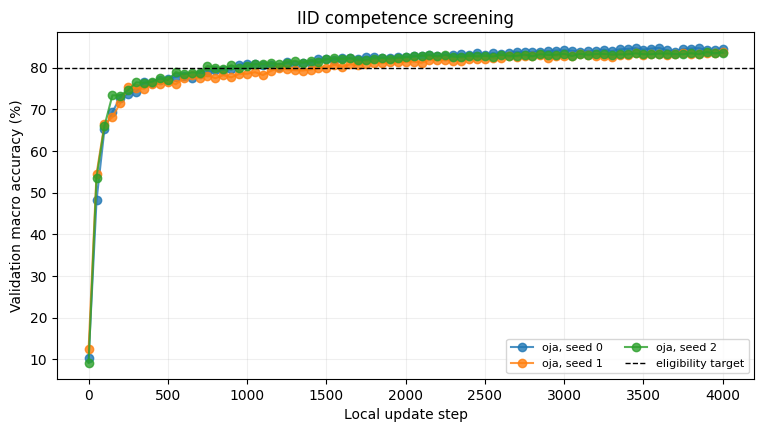

In [ ]:
iid_curve_df = pd.DataFrame([
    {key: value for key, value in row.items() if not isinstance(value, (dict, list))}
    for row in iid_records
])

fig, ax = plt.subplots(figsize=(9, 4.5))
for (variant, seed), group in iid_curve_df.groupby(['variant', 'seed']):
    ax.plot(
        group['step'], group['valid_joint_macro_accuracy'],
        marker='o', alpha=0.8, label=f'{variant}, seed {seed}',
    )
ax.axhline(80, color='black', linestyle='--', linewidth=1, label='eligibility target')
ax.set(
    xlabel='Local update step',
    ylabel='Validation macro accuracy (%)',
    title='IID competence screening',
)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.show()

## 6. Frozen continual-learning experiment

The selected model learns digits 0-4 once. That exact state is copied into both phase-two conditions:

- **Sequential:** only digits 5-9 are available.
- **Interleaved control:** every batch contains 50% old and 50% new examples.

The primary result is forgetting at the first checkpoint reaching 80% new-class macro validation accuracy.

In [ ]:
if SELECTED_CONFIG is None:
    raise RuntimeError(
        'No candidate passed the IID gate. Adjust hyperparameters using IID validation only, '
        'then restart and rerun the notebook. Do not use forgetting to choose a model.'
    )

continual_runs = []
for seed in FINAL_SEEDS:
    experiment = replace(BASE_EXPERIMENT, seed=seed)
    datasets_for_seed, loaders_for_seed = build_mnist_protocol(
        full_train_dataset, test_dataset, experiment
    )
    result = run_continual_experiment(
        SELECTED_CONFIG, experiment, datasets_for_seed, loaders_for_seed
    )
    continual_runs.append(result)
    old_before = result['phase1_records'][-1]['valid_old_macro_accuracy']
    print(f'\nSeed {seed}: old accuracy before phase two = {old_before:.2f}%')
    for condition, condition_result in result['conditions'].items():
        print(condition, forgetting_at_target(old_before, condition_result['records'], 80.0))


Seed 0: old accuracy before phase two = 90.62%
sequential {'target': 80.0, 'target_reached': True, 'matched_step': 100, 'retained_old_accuracy': 0.0, 'new_accuracy': 80.72775673134943, 'joint_accuracy': 40.363878365674715, 'forgetting': 90.62233956683163}
interleaved {'target': 80.0, 'target_reached': True, 'matched_step': 1400, 'retained_old_accuracy': 84.26572215972112, 'new_accuracy': 80.48061160583526, 'joint_accuracy': 82.37316688277818, 'forgetting': 6.356617407110505}

Seed 1: old accuracy before phase two = 90.66%
sequential {'target': 80.0, 'target_reached': True, 'matched_step': 100, 'retained_old_accuracy': 0.0, 'new_accuracy': 82.31300083751596, 'joint_accuracy': 41.15650041875798, 'forgetting': 90.662630800712}
interleaved {'target': 80.0, 'target_reached': True, 'matched_step': 2200, 'retained_old_accuracy': 82.48637931425927, 'new_accuracy': 80.26872562117323, 'joint_accuracy': 81.37755246771624, 'forgetting': 8.176251486452728}

Seed 2: old accuracy before phase two = 

In [ ]:
continual_rows = []
matched_rows = []

for result in continual_runs:
    seed = result['experiment_config']['seed']
    old_before = result['phase1_records'][-1]['valid_old_macro_accuracy']
    for condition, condition_result in result['conditions'].items():
        continual_rows.extend(condition_result['records'])
        for target in BASE_EXPERIMENT.matched_new_accuracies:
            matched_rows.append({
                'seed': seed,
                'variant': SELECTED_CONFIG.variant,
                'condition': condition,
                'old_accuracy_before_phase2': old_before,
                **forgetting_at_target(old_before, condition_result['records'], target),
            })

continual_scalar_df = pd.DataFrame([
    {key: value for key, value in row.items() if not isinstance(value, (dict, list))}
    for row in continual_rows
])
matched_df = pd.DataFrame(matched_rows)
display(matched_df)

primary_summary = (
    matched_df[matched_df['target'] == 80.0]
    .groupby('condition', as_index=False)
    .agg(
        target_reach_rate=('target_reached', 'mean'),
        mean_old_before=('old_accuracy_before_phase2', 'mean'),
        mean_retained_old=('retained_old_accuracy', 'mean'),
        mean_forgetting=('forgetting', 'mean'),
        std_forgetting=('forgetting', 'std'),
        mean_new_accuracy=('new_accuracy', 'mean'),
        mean_joint_accuracy=('joint_accuracy', 'mean'),
    )
)
primary_summary['std_forgetting'] = primary_summary['std_forgetting'].fillna(0.0)
display(primary_summary)

,seed,variant,condition,old_accuracy_before_phase2,target,target_reached,matched_step,retained_old_accuracy,new_accuracy,joint_accuracy,forgetting
0,0,oja,sequential,90.622340,70.0,True,50.0,6.888634,73.962426,40.425530,83.733706
1,0,oja,sequential,90.622340,80.0,True,100.0,0.000000,80.727757,40.363878,90.622340
2,0,oja,sequential,90.622340,90.0,True,1650.0,0.000000,90.243041,45.121520,90.622340
3,0,oja,interleaved,90.622340,70.0,True,450.0,81.556957,72.534085,77.045521,9.065383
4,0,oja,interleaved,90.622340,80.0,True,1400.0,84.265722,80.480612,82.373167,6.356617
5,0,oja,interleaved,90.622340,90.0,False,NaN,NaN,NaN,NaN,NaN
6,1,oja,sequential,90.662631,70.0,True,50.0,0.068886,74.811795,37.440341,90.593744
7,1,oja,sequential,90.662631,80.0,True,100.0,0.000000,82.313001,41.156500,90.662631
8,1,oja,sequential,90.662631,90.0,True,1650.0,0.000000,90.243452,45.121726,90.662631
9,1,oja,interleaved,90.662631,70.0,True,400.0,81.048294,71.549597,76.298946,9.614336


,condition,target_reach_rate,mean_old_before,mean_retained_old,mean_forgetting,std_forgetting,mean_new_accuracy,mean_joint_accuracy
0,interleaved,1.0,90.691575,83.605726,7.085850,0.666379,80.299823,81.952774
1,sequential,1.0,90.691575,0.004592,90.686983,0.384436,82.161005,41.082799


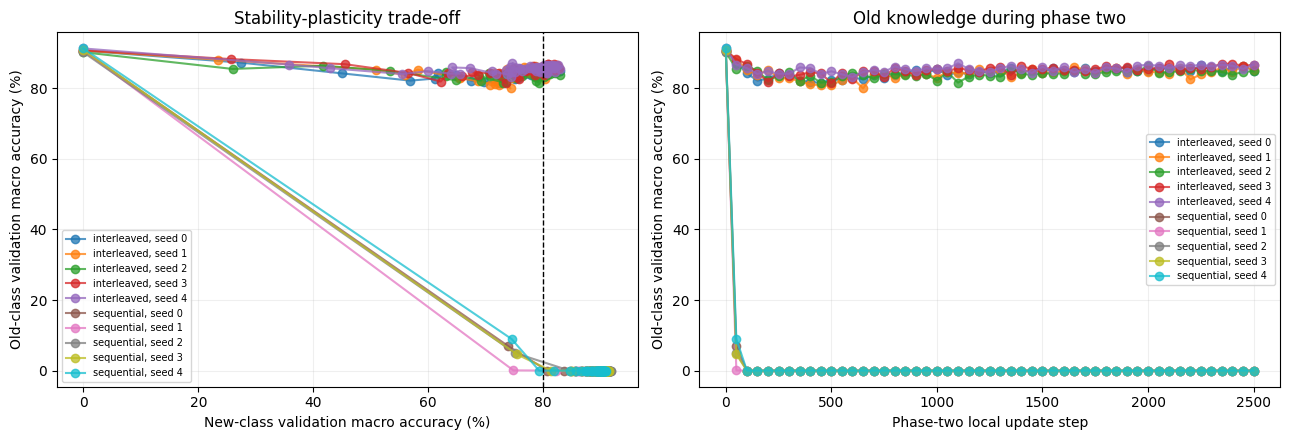

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for (condition, seed), group in continual_scalar_df.groupby(['condition', 'seed']):
    axes[0].plot(
        group['valid_new_macro_accuracy'], group['valid_old_macro_accuracy'],
        marker='o', alpha=0.75, label=f'{condition}, seed {seed}',
    )
    axes[1].plot(
        group['step'], group['valid_old_macro_accuracy'],
        marker='o', alpha=0.75, label=f'{condition}, seed {seed}',
    )
axes[0].axvline(80, color='black', linestyle='--', linewidth=1)
axes[0].set(
    xlabel='New-class validation macro accuracy (%)',
    ylabel='Old-class validation macro accuracy (%)',
    title='Stability-plasticity trade-off',
)
axes[1].set(
    xlabel='Phase-two local update step',
    ylabel='Old-class validation macro accuracy (%)',
    title='Old knowledge during phase two',
)
for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Per-digit and confusion-matrix validation results

These plots use the first seed's first checkpoint crossing 80% new validation accuracy. Aggregate conclusions must still use all seeds.

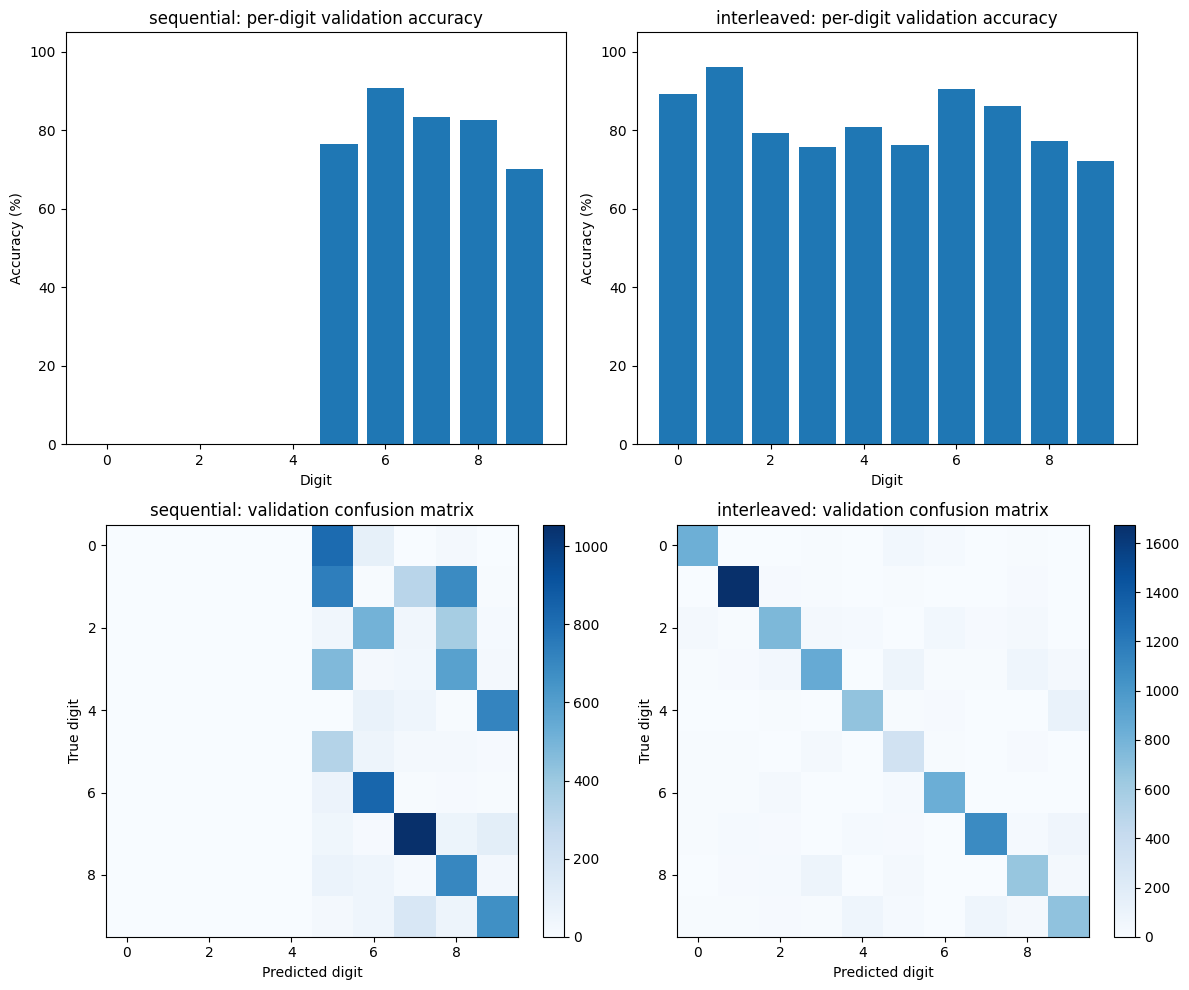

In [ ]:
first_run = continual_runs[0]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for column, condition in enumerate(('sequential', 'interleaved')):
    records = first_run['conditions'][condition]['records']
    matched = first_record_at_target(records, 'valid_new_macro_accuracy', 80.0)
    if matched is None:
        axes[0, column].text(0.5, 0.5, '80% target not reached', ha='center', va='center')
        axes[1, column].text(0.5, 0.5, '80% target not reached', ha='center', va='center')
        continue

    old_scores = matched['valid_old_per_class_accuracy']
    new_scores = matched['valid_new_per_class_accuracy']
    scores = {**old_scores, **new_scores}
    axes[0, column].bar(list(scores.keys()), list(scores.values()))
    axes[0, column].set(
        title=f'{condition}: per-digit validation accuracy',
        xlabel='Digit', ylabel='Accuracy (%)', ylim=(0, 105),
    )

    confusion = np.asarray(matched['valid_joint_confusion_matrix'])
    image = axes[1, column].imshow(confusion, cmap='Blues')
    axes[1, column].set(
        title=f'{condition}: validation confusion matrix',
        xlabel='Predicted digit', ylabel='True digit',
    )
    fig.colorbar(image, ax=axes[1, column], fraction=0.046)

plt.tight_layout()
plt.show()

## 8. Local-update diagnostics

Hebbian quantities are called **proposed updates**, not gradients. We measure their signal-to-noise ratio and cosine alignment with the negative backpropagation gradient that the same network would receive.

In [ ]:
diagnostic_run = continual_runs[0]
diagnostic_seed = diagnostic_run['experiment_config']['seed']
diagnostic_experiment = replace(BASE_EXPERIMENT, seed=diagnostic_seed)
diagnostic_datasets, diagnostic_loaders = build_mnist_protocol(
    full_train_dataset, test_dataset, diagnostic_experiment
)
diagnostic_model = HebbianMLP(SELECTED_CONFIG).to(diagnostic_experiment.device)
diagnostic_model.load_state_dict(diagnostic_run['phase1_state'])

alignment_metrics = alignment_over_loader(
    diagnostic_model, diagnostic_loaders['valid_joint'], max_batches=10
)
snr_metrics = update_snrs(
    diagnostic_model,
    diagnostic_datasets['valid_joint'],
    batch_size=BASE_EXPERIMENT.batch_size,
    max_batches=16,
)

print('Cosine alignment with backpropagation descent:', alignment_metrics)
print('Local-update signal-to-noise:', snr_metrics)

Cosine alignment with backpropagation descent: {'lin1_weight': -0.048885709315072745, 'lin2_weight': 1.000000011920929}
Local-update signal-to-noise: {'lin1_weight': {'elementwise_snr': 0.6758435368537903, 'vector_snr': 1.0247819423675537}, 'lin2_weight': {'elementwise_snr': 2.3715734481811523, 'vector_snr': 2.815981149673462}}


## 9. One-time official test evaluation

Only set `RUN_FINAL_TEST=True` after `QUICK_RUN=False`, IID selection is complete, the winner is frozen, and you will not change any hyperparameter afterward.

In [ ]:
if not RUN_FINAL_TEST:
    print('Official test evaluation skipped. This is correct during development and selection.')
    test_rows = []
    test_summary_df = pd.DataFrame()
else:
    if QUICK_RUN:
        raise RuntimeError('Do not evaluate the official test set in QUICK_RUN mode.')
    missing_checkpoints = [
        (result['experiment_config']['seed'], condition)
        for result in continual_runs
        for condition, condition_result in result['conditions'].items()
        if condition_result['checkpoint_states'].get(80.0) is None
    ]
    if missing_checkpoints:
        raise RuntimeError(
            'Official test evaluation blocked because the 80% new-validation target '
            f'was not reached for: {missing_checkpoints}. The forgetting comparison is inconclusive.'
        )
    test_rows = []
    for result in continual_runs:
        seed = result['experiment_config']['seed']
        experiment = replace(BASE_EXPERIMENT, seed=seed)
        _, loaders_for_seed = build_mnist_protocol(full_train_dataset, test_dataset, experiment)
        test_loaders = {
            name: loader for name, loader in loaders_for_seed.items()
            if name.startswith('test_')
        }
        for condition, condition_result in result['conditions'].items():
            state = condition_result['checkpoint_states'].get(80.0)
            if state is None:
                test_rows.append({'seed': seed, 'condition': condition, 'target_reached': False})
                continue
            model = HebbianMLP(SELECTED_CONFIG).to(experiment.device)
            model.load_state_dict(state)
            metrics = evaluate_named_loaders(model, test_loaders, experiment.device)
            test_rows.append({
                'seed': seed,
                'condition': condition,
                'target_reached': True,
                **metrics,
            })
    test_summary_df = pd.DataFrame([
        {key: value for key, value in row.items() if not isinstance(value, (dict, list))}
        for row in test_rows
    ])
    display(test_summary_df)

,seed,condition,target_reached,test_joint_loss,test_joint_micro_accuracy,test_joint_macro_accuracy,test_old_loss,test_old_micro_accuracy,test_old_macro_accuracy,test_new_loss,test_new_micro_accuracy,test_new_macro_accuracy
0,0,sequential,True,2.659888,40.11,41.246670,4.486528,0.000000,0.000000,0.728783,82.513886,82.493339
1,0,interleaved,True,0.558447,83.16,82.888057,0.482750,85.755984,85.514126,0.638472,80.415552,80.261989
2,1,sequential,True,2.854714,40.59,41.740405,4.837989,0.000000,0.000000,0.758015,83.501337,83.480810
3,1,interleaved,True,0.550664,82.98,82.684432,0.496687,83.985211,83.642450,0.607727,81.917301,81.726414
4,2,sequential,True,2.698440,40.30,41.449047,4.542558,0.000000,0.000000,0.748857,82.904752,82.898095
5,2,interleaved,True,0.595937,81.58,81.352604,0.528384,84.705196,84.482587,0.667352,78.276075,78.222620
6,3,sequential,True,2.668313,40.11,41.269393,4.537269,0.019459,0.017621,0.692472,82.493314,82.521164
7,3,interleaved,True,0.566342,82.97,82.654478,0.479252,85.444639,85.178282,0.658413,80.353837,80.130674
8,4,sequential,True,2.886406,40.28,41.464773,5.029826,0.000000,0.000000,0.620405,82.863608,82.929546
9,4,interleaved,True,0.565915,83.01,82.686416,0.484127,85.483557,85.169196,0.652380,80.394980,80.203636


## 10. Export results and checkpoints

Quick outputs are clearly separated from final outputs. The generated Markdown summary can be copied into `hebbian/REPORT.md` after the locked full run.

In [ ]:
OUTPUT_DIR = Path('/content/hebbian_results_quick' if QUICK_RUN else '/content/hebbian_results_final')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

iid_export = iid_summary_df.copy()
iid_export['per_class_accuracy'] = iid_export['per_class_accuracy'].map(json.dumps)
iid_export.to_csv(OUTPUT_DIR / 'iid_selection.csv', index=False)
selection_table.to_csv(OUTPUT_DIR / 'selection_table.csv', index=False)
iid_curve_df.to_csv(OUTPUT_DIR / 'iid_trajectories.csv', index=False)
continual_scalar_df.to_csv(OUTPUT_DIR / 'continual_trajectories.csv', index=False)
matched_df.to_csv(OUTPUT_DIR / 'matched_forgetting.csv', index=False)
primary_summary.to_csv(OUTPUT_DIR / 'primary_summary.csv', index=False)

with (OUTPUT_DIR / 'continual_details.json').open('w') as handle:
    json.dump(continual_rows, handle, indent=2)
with (OUTPUT_DIR / 'update_alignment.json').open('w') as handle:
    json.dump(alignment_metrics, handle, indent=2)
with (OUTPUT_DIR / 'update_snr.json').open('w') as handle:
    json.dump(snr_metrics, handle, indent=2)
if len(test_summary_df):
    test_summary_df.to_csv(OUTPUT_DIR / 'final_test_metrics.csv', index=False)
    with (OUTPUT_DIR / 'final_test_details.json').open('w') as handle:
        json.dump(test_rows, handle, indent=2)

run_config = {
    'quick_run': QUICK_RUN,
    'run_final_test': RUN_FINAL_TEST,
    'screen_seeds': SCREEN_SEEDS,
    'final_seeds': FINAL_SEEDS,
    'experiment': asdict(BASE_EXPERIMENT),
    'all_candidates': [asdict(config) for config in ALL_CANDIDATES],
    'active_candidates': [asdict(config) for config in CANDIDATES],
    'selected': asdict(SELECTED_CONFIG),
    'torch_version': torch.__version__,
    'torchvision_version': torchvision.__version__,
}
with (OUTPUT_DIR / 'run_config.json').open('w') as handle:
    json.dump(run_config, handle, indent=2)

for result in continual_runs:
    seed = result['experiment_config']['seed']
    torch.save(result['phase1_state'], OUTPUT_DIR / f'seed_{seed}_phase1.pt')
    for condition, condition_result in result['conditions'].items():
        for target, state in condition_result['checkpoint_states'].items():
            torch.save(state, OUTPUT_DIR / f'seed_{seed}_{condition}_new_{int(target)}.pt')

summary_markdown = f"""# Hebbian run summary

Mode: **{'QUICK / NOT REPORTABLE' if QUICK_RUN else 'FULL LOCKED RUN'}**

Selected configuration:

```json
{json.dumps(asdict(SELECTED_CONFIG), indent=2)}
```

## IID selection

{selection_table.to_markdown(index=False)}

## Forgetting at 80% new validation accuracy

{primary_summary.to_markdown(index=False)}

The official test set was {'evaluated' if RUN_FINAL_TEST else 'not evaluated'} in this run.
"""
(OUTPUT_DIR / 'RESULTS_SUMMARY.md').write_text(summary_markdown)

archive_path = shutil.make_archive(str(OUTPUT_DIR), 'zip', OUTPUT_DIR)
print('Saved:', OUTPUT_DIR)
print('Downloadable archive:', archive_path)

Saved: /content/hebbian_results_final
Downloadable archive: /content/hebbian_results_final.zip


In [ ]:
from google.colab import files
files.download(str(OUTPUT_DIR) + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation rules

- Less forgetting in the fixed-capacity Hebbian model at matched new competence supports a contribution from the local learning rule in this MNIST model.
- Similar or worse forgetting suggests that the local rule alone is insufficient here and additional systems-level mechanisms may be required.
- Failure to pass the IID, old-task, or new-task competence gates makes the forgetting comparison inconclusive.
- A wider SoftHebb model, replay, freezing, expansion, task-specific heads, or consolidation must be reported separately as architecture-plus-rule evidence.
- Do not compare these results directly with the current predictive-coding notebook's `98.96% -> 0%` result unless predictive coding is rerun under the same data, architecture, seed, and matched-accuracy protocol.